# Frequency of Volatile-Rich Zones vs. Distance from Lander

In [2]:
# general setup: import packages and libraries and whatnot
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

In [10]:
# create a function to read file
def load_final_marsquakes_df(filename): #take filename as only input
    
    # these are the column names used in the file
    cols = ['Event_ID', 'Distance_Degrees', 'Distance_KM', 't0', 'tp', 'ts', 'Vp_Vs_Ratio']
    
    # dataframe from csv (access by filename, column names separated by ',', skip the first row (column names) to skip to the data)
    df = pd.read_csv(filename, sep=',', names=cols, on_bad_lines='skip', skiprows= 1)

    # give the data frame (column names and data sorted into rows)
    return df

# use file path to access the csv (go backwards, then to data, then to specific file)
df_a = load_final_marsquakes_df('../data/final_marsquakes_data_frame.csv')
df_b = df_a[(df_a['Distance_KM']>=1300) & (df_a['Distance_KM']<=1900)].copy()

# create a new dataframe for potential volatile zones from just the Vp/Vs ratios between 1.8 and 2.1 - these are what we determined to be abnormalities compared to dry rock (see other notebooks for more explaination)
volatile_zone = df_a[(df_a['Vp_Vs_Ratio'] >= 1.80) & (df_a['Vp_Vs_Ratio'] <= 2.10)].copy() #copy makes a new dataframe instead of changing the old one
volatile_zone= volatile_zone[(volatile_zone['Distance_KM']<=3000)] #get rid of outliers - we could see from using all the distances that most of the data was less than 3000 km, with 2-3 outliers
# removing outliers gives us a more detailed look at where probabilites are highest because we get to zoom in on the "important" part of the plot

# depth is ~12% of the surface distance, didn't end up using this, but you would if you wanted a plot for most probable depths to find volatile-rich zones
volatile_zone['Est_Depth_KM'] = volatile_zone['Distance_KM'] * 0.12

# let's see the first 10 rows!
volatile_zone.head(10)

,Event_ID,Distance_Degrees,Distance_KM,t0,tp,ts,Vp_Vs_Ratio,Est_Depth_KM
10,S0820a,30.19,1787.248,2021-03-18T14:51:33.869889Z,2021-03-18T14:54:39.0Z,2021-03-18T14:57:39.0Z,1.972289,214.46976
14,S1197a,31.98,1893.216,2022-04-09T22:05:52.41687Z,2022-04-09T22:09:38.5Z,2022-04-09T22:12:49.0Z,1.842610,227.18592
15,S1192a,25.50,1509.600,2022-04-04T23:06:52.616746Z,2022-04-04T23:12:12.572401Z,2022-04-04T23:16:48.265836Z,1.861661,181.15200
16,S1163a,23.10,1367.520,2022-03-06T02:29:13.668752Z,2022-03-06T02:34:18.697973Z,2022-03-06T02:38:28.753599Z,1.819776,164.10240
23,S1094d,24.40,1444.480,2021-12-25T03:31:41.685086Z,2021-12-25T03:36:52.573319Z,2021-12-25T03:41:16.658691Z,1.849454,173.33760
27,S1086d,24.90,1474.080,2021-12-16T23:02:32.671075Z,2021-12-16T23:07:42.4055Z,2021-12-16T23:12:11.468547Z,1.868690,176.88960
29,S1077c,23.00,1361.600,2021-12-07T14:01:49.15588Z,2021-12-07T14:06:59.285347Z,2021-12-07T14:11:08.381859Z,1.803202,163.39200
30,S1075c,25.60,1515.520,2021-12-05T14:43:47.693762Z,2021-12-05T14:49:10.902171Z,2021-12-05T14:53:48.242672Z,1.858086,181.86240
31,S1073d,26.50,1568.800,2021-12-03T14:28:52.584603Z,2021-12-03T14:33:57.521266Z,2021-12-03T14:38:44.069111Z,1.939696,188.25600
32,S1071b,25.00,1480.000,2021-12-01T12:19:05.491437Z,2021-12-01T12:24:25.3756Z,2021-12-01T12:28:55.650274Z,1.844914,177.60000


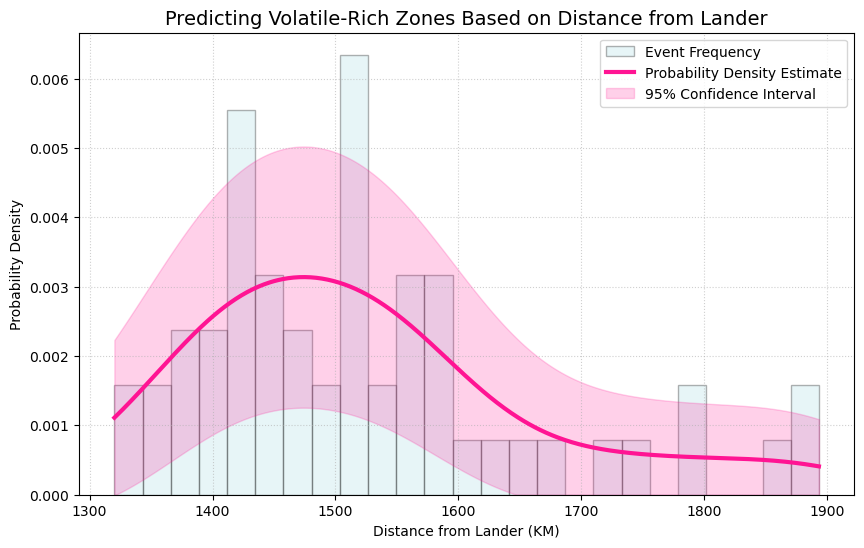

In [ ]:

dist = volatile_zone['Distance_KM'].values # creates a vector containing all the distance values
n = len(dist) # n is the number of observations we have
color = 'deeppink' # hello women in stem!

fig, ax1 = plt.subplots(figsize=(10, 6)) # basic setup of the plot

# create the histogram using 25 bins to separate the distances into
# density= true makes the area under the curve 1, which means the area of each bar represents the probability that a data point falls within the bin's range of distances (basically makes the y-axis probability density)
# rest of the command is just visuals (colors, lines, making things pretty!)
n_hist, bins, patches = ax1.hist(dist, bins=25, density=True, color='powderblue', 
                                 edgecolor='black', alpha=0.3, label='Event Frequency')

# the trendline
kde = gaussian_kde(dist) #kde is kernel density estimation from the scipy library. this one uses gaussian quadrature/ lets the data determine the shape instead of assuming a specific shape
dist_range = np.linspace(min(dist), max(dist), 500) # create a linearly spaced vector with 500 entries from the min to max values
trend_density = kde(dist_range) # heres the trendline!

# confidence interval
z_score = 1.96 # the z-score for 2 standard deviations from the mean (ie a 95% CI)
bandwidth = kde.factor * np.std(dist) # scipy's internal smoothing factor
std_err = np.sqrt(trend_density / (n * bandwidth)) # calculate the standard error at every point from the basic formula
ci = z_score * std_err # confidence interval (this will be +/- the trend density everywhere)
# the way we did this means theres a 95% confidence interval for every point

# plotting the trendline
ax1.plot(dist_range, trend_density, color=color, linewidth=3, label='Probability Density Estimate')

# fill in the confidence interval
ax1.fill_between(dist_range, 
                 np.maximum(0, trend_density - ci), # heres the part where its CI +/- trend density
                 trend_density + ci, 
                 color=color, alpha=0.2, label='95% Confidence Interval')
# we are 95% confident that the true distribution of volatile-rich zones lies within the shaded pink region, assuming the data represents a random sampling of marsquakes.

# the final visual details
ax1.set_title('Predicting Volatile-Rich Zones Based on Distance from Lander', fontsize=14)
ax1.set_xlabel('Distance from Lander (KM)')
ax1.set_ylabel('Probability Density')
ax1.grid(ls='dotted', alpha=0.6)
ax1.legend()

plt.show()

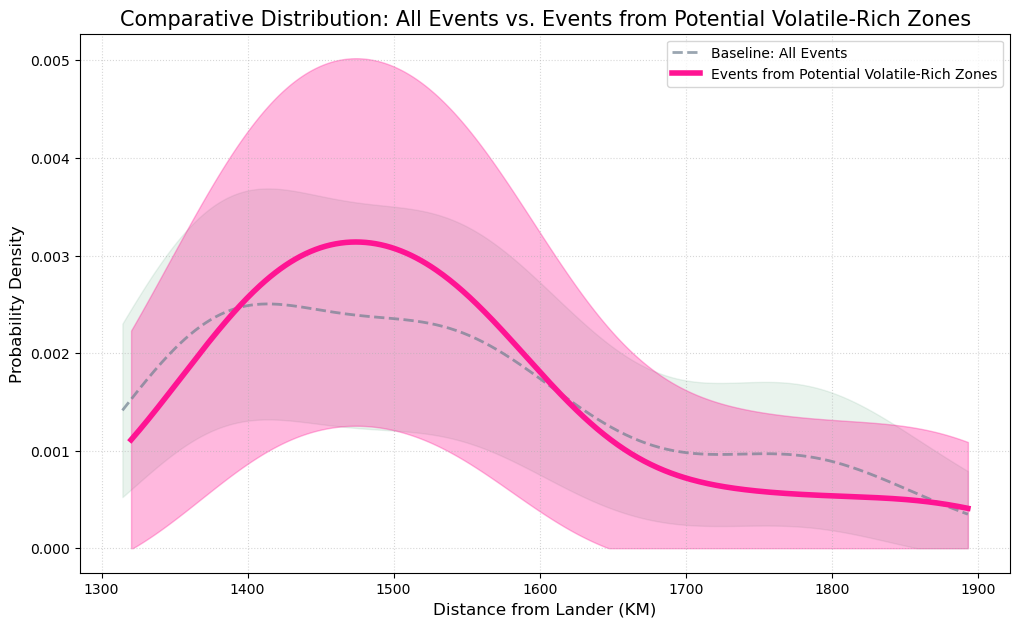

In [16]:
dist_total = df_b['Distance_KM'].values 
dist_volatile = volatile_zone['Distance_KM'].values

fig, ax1 = plt.subplots(figsize=(12, 7))

kde_total = gaussian_kde(dist_total)
x_total = np.linspace(min(dist_total), max(dist_total), 500)
y_total = kde_total(x_total)

n_total = len(dist_total)
bw_total = kde_total.factor * np.std(dist_total)
ci_total = 1.96 * np.sqrt(y_total / (n_total * bw_total))

# Plot Baseline in Grey
ax1.plot(x_total, y_total, color='slategrey', linewidth=2, linestyle='--', label='Baseline: All Events', alpha=0.7)
ax1.fill_between(x_total, np.maximum(0, y_total - ci_total), y_total + ci_total, color='seagreen', alpha=0.1)

# --- PLOT 2: VOLATILE-RICH ZONES (The Signal) ---
kde_volatile = gaussian_kde(dist_volatile)
x_volatile = np.linspace(min(dist_volatile), max(dist_volatile), 500)
y_volatile = kde_volatile(x_volatile)

# Volatile Stats for Cloud
n_volatile = len(dist_volatile)
bw_volatile = kde_volatile.factor * np.std(dist_volatile)
ci_volatile = 1.96 * np.sqrt(y_volatile / (n_volatile * bw_volatile))

# Plot Signal in Pink
ax1.plot(x_volatile, y_volatile, color='deeppink', linewidth=4, label='Events from Potential Volatile-Rich Zones')
ax1.fill_between(x_volatile, np.maximum(0, y_volatile - ci_volatile), y_volatile + ci_volatile, color='deeppink', alpha=0.3)

# 3. Final Polish
ax1.set_title('Comparative Distribution: All Events vs. Events from Potential Volatile-Rich Zones', fontsize=15)
ax1.set_xlabel('Distance from Lander (KM)', fontsize=12)
ax1.set_ylabel('Probability Density', fontsize=12)
ax1.grid(ls='dotted', alpha=0.5)
ax1.legend(loc='upper right', frameon=True)

plt.show()

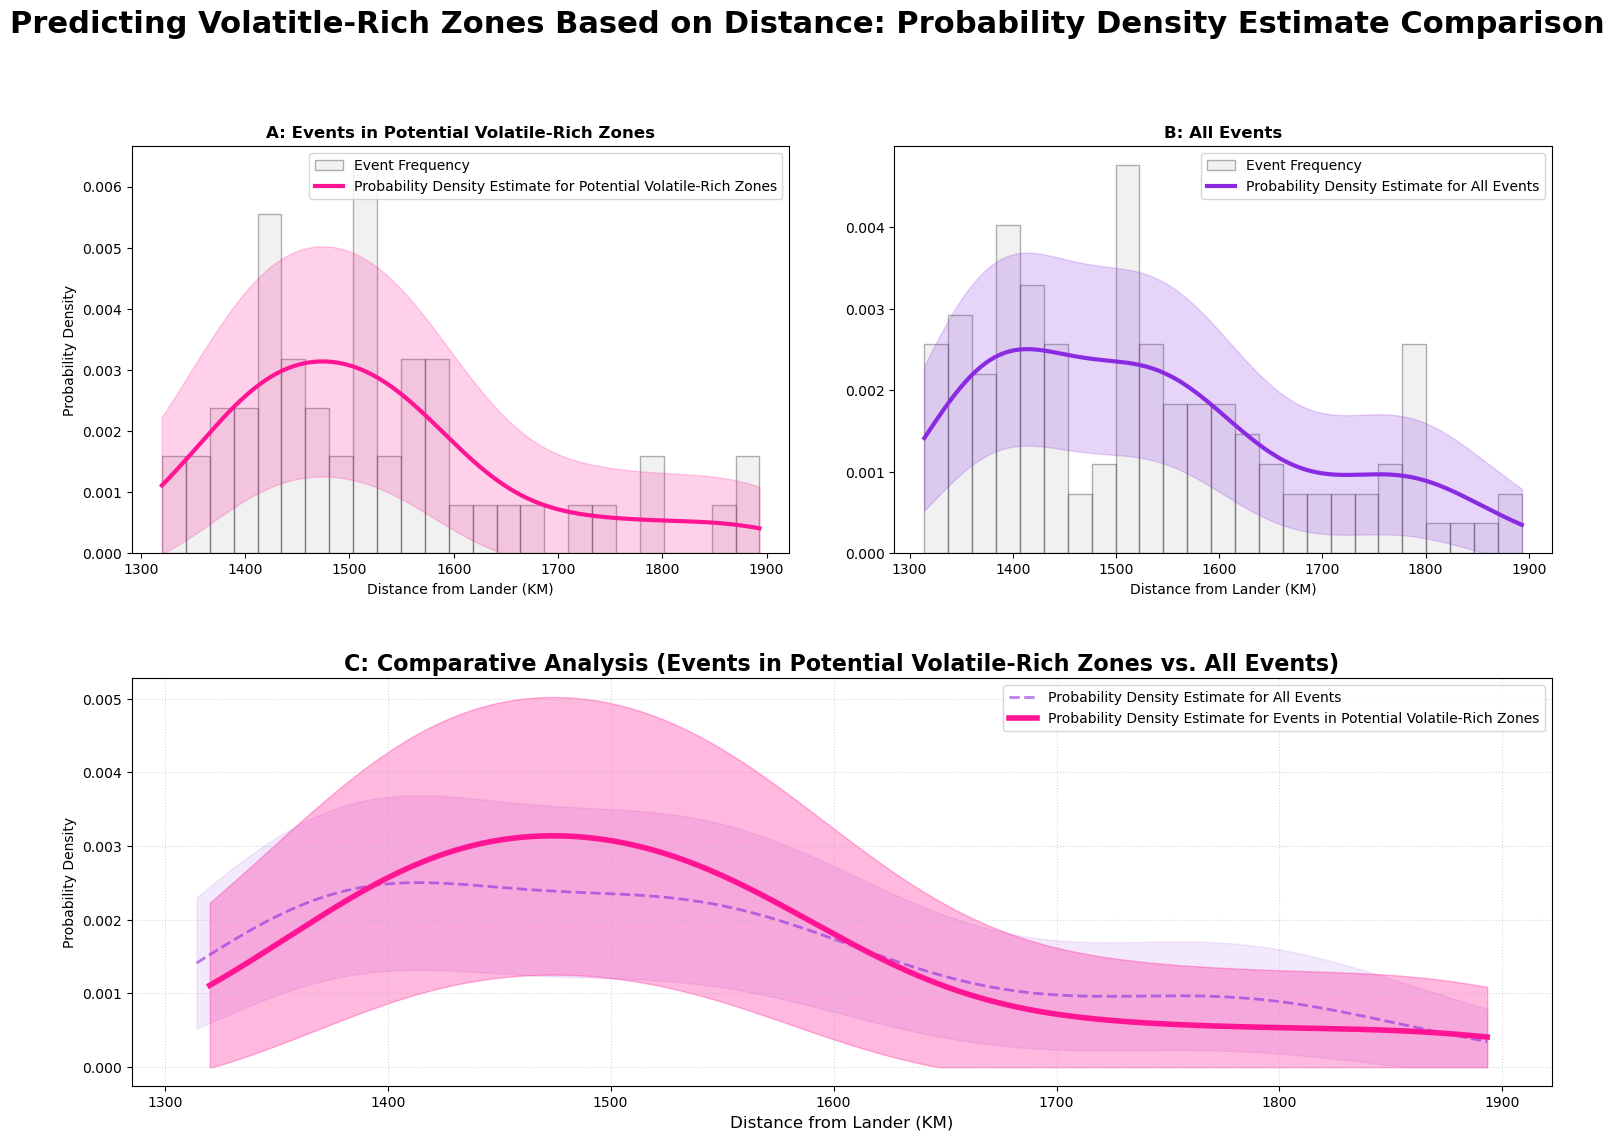

In [28]:
# dist_total refers to all events recorded and dist_volatile refers to only events with suspected volatitle-rich zones based on the Vp/Vs ratio
dist_total = df_b['Distance_KM'].values                 # both of these create vector of all the distances for each set
dist_volatile = volatile_zone['Distance_KM'].values

# basic plot setup
fig = plt.figure(figsize=(16, 12)) #how big the figure is
ax1 = plt.subplot2grid((2, 2), (0, 0)) # top left
ax2 = plt.subplot2grid((2, 2), (0, 1)) # top right
ax3 = plt.subplot2grid((2, 2), (1, 0), colspan=2) # bottom, spans between the two upper plots

# make a function to help with the heavy lifting
def get_kde_data(data): # takes distance vectors as "data"
    kde = gaussian_kde(data) # kde is kernel density estimation from the scipy library. this one uses gaussian quadrature/ lets the data determine the shape instead of assuming a specific shape
    x = np.linspace(min(data), max(data), 500) #make a linearly spaced vector that spans from the min to the max values of the data with 500 entries
    y = kde(x) # trendline!
    bw = kde.factor * np.std(data) # scipy's internal smoothing factor
    ci = 1.96 * np.sqrt(y / (len(data) * bw)) # confidence interval (this will be +/- the trend density everywhere), 1.96 is the z-score for a 95% CI
    # the way we did this means theres a 95% confidence interval for every point
    return x, y, ci

x_v, y_v, ci_v = get_kde_data(dist_volatile) # use the function to make the trendline and get info about the CI
x_t, y_t, ci_t = get_kde_data(dist_total) # the notation here has v for volatile and t for total

# plot the Probability Density Estimate for potential volatile-rich zones
ax1.hist(dist_volatile, bins=25, density=True, color='lightgrey', edgecolor='black', alpha=0.3, label= 'Event Frequency') #these are the histogram bars. 
# create the histogram using 25 bins to separate the distances into
# density= true makes the area under the curve 1, which means the area of each bar represents the probability that a data point falls within the bin's range of distances (basically makes the y-axis probability density)
# rest of the command is just visuals (colors, lines, making things pretty!)
ax1.plot(x_v, y_v, color='deeppink', linewidth=3, label='Probability Density Estimate for Potential Volatile-Rich Zones') #this is the trendline, plotted using the values from using the kde function above
ax1.fill_between(x_v, np.maximum(0, y_v - ci_v), y_v + ci_v, color='deeppink', alpha=0.2) # fill in the confidence interval. this is the part where its CI +/- trend density
ax1.set_title('A: Events in Potential Volatile-Rich Zones', fontweight='bold')
ax1.set_ylabel('Probability Density')
ax1.set_xlabel('Distance from Lander (KM)')
ax1.legend()

# plot the Probability Density Estimate for all events (rinse and repeat with above plot)
ax2.hist(dist_total, bins=25, density=True, color='lightgrey', edgecolor='black', alpha=0.3, label= 'Event Frequency')
ax2.plot(x_t, y_t, color='blueviolet', linewidth=3, label='Probability Density Estimate for All Events')
ax2.fill_between(x_t, np.maximum(0, y_t - ci_t), y_t + ci_t, color='blueviolet', alpha=0.2)
ax2.set_title('B: All Events', fontweight='bold')
ax2.set_xlabel('Distance from Lander (KM)')
ax2.legend()

# now we compare the two by overlaying!
# baseline in background
ax3.plot(x_t, y_t, color='blueviolet', lw=2, ls='--', label='Probability Density Estimate for All Events', alpha=0.6)
ax3.fill_between(x_t, np.maximum(0, y_t - ci_t), y_t + ci_t, color='blueviolet', alpha=0.1)
# volatiles in front
ax3.plot(x_v, y_v, color='deeppink', lw=4, label='Probability Density Estimate for Events in Potential Volatile-Rich Zones')
ax3.fill_between(x_v, np.maximum(0, y_v - ci_v), y_v + ci_v, color='deeppink', alpha=0.3)

# set formatting (titles, axes, grids, legends)
ax3.set_title('C: Comparative Analysis (Events in Potential Volatile-Rich Zones vs. All Events)', fontweight='bold', fontsize=16)
ax3.set_xlabel('Distance from Lander (KM)', fontsize=12)
ax3.set_ylabel('Probability Density')
ax3.grid(ls='dotted', alpha=0.5)
ax3.legend(loc='upper right') #location of the legend upper right to make more readable

fig.suptitle('Predicting Volatitle-Rich Zones Based on Distance: Probability Density Estimate Comparison', 
             fontsize=22, fontweight='bold', y=0.98) #add a big title to the whole thing
plt.subplots_adjust(top=0.90) #make room for the big title!

# layout changes, and show the plot
plt.tight_layout(pad=4.0)
plt.show()